In [3]:
# change file type pandas or numpy
import pandas as pd
import numpy as np

# 온라인(외부에서) 불러오기
from sklearn import datasets

iris = datasets.load_iris()
iris # 딕셔너리로 load됨

df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


classfication

In [4]:
clf_df = df # move df to classfication df
y = clf_df['target']             # target
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [5]:
X = clf_df.drop('target', axis=1) # fitting data
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lg_model = LogisticRegression(random_state=0)
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeClassifier(random_state=0)
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestClassifier(random_state=0)
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsClassifier(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score # 정확도
from sklearn.metrics import confusion_matrix #혼동행렬 ==> k fold

print('---- logistic regression ----')
print(accuracy_score(y_test, lg_y))
print(confusion_matrix(y_test, lg_y))

print('---- decision tree classifier ----')
print(accuracy_score(y_test, De_y))
print(confusion_matrix(y_test, De_y))

print('---- random forest classifier ----')
print(accuracy_score(y_test, Rd_y))
print(confusion_matrix(y_test, Rd_y))

print('---- KNeighborsClassifier ----')
print(accuracy_score(y_test, KN_y))
print(confusion_matrix(y_test, KN_y))

---- logistic regression ----
0.9736842105263158
[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
---- decision tree classifier ----
0.9736842105263158
[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
---- random forest classifier ----
0.9736842105263158
[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
---- KNeighborsClassifier ----
0.9736842105263158
[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]


In [9]:
# k value 최적화



regression

In [10]:
# 데이터 상관관계 확인
import seaborn as sns
import matplotlib.pyplot as plt

reg_df = df # move df to classfication df
reg_df = reg_df.drop('target', axis=1)
reg_df
# corr = reg_df.corr()

# #sns.heatmap(corr, annot=True, fmt='.0f', cmap='coolwarm')
# sns.heatmap(corr)
# plt.show()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
y = reg_df['sepal length (cm)']             # target
y.head() 

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: sepal length (cm), dtype: float64

In [12]:
X = reg_df.drop('sepal length (cm)', axis=1) # fitting data
X.head()

,sepal width (cm),petal length (cm),petal width (cm)
0,3.5,1.4,0.2
1,3.0,1.4,0.2
2,3.2,1.3,0.2
3,3.1,1.5,0.2
4,3.6,1.4,0.2


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

lg_model = LinearRegression()
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeRegressor()
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestRegressor()
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsRegressor(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,lg_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,De_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,Rd_y))
print('---- KNeighborsRegressor ----')
print(mean_squared_error(y_test,KN_y))

---- LinearRegression ----
0.12305100431451685
---- DecisionTreeRegressor ----
0.12305100431451685
---- RandomForestRegressor ----
0.12305100431451685
---- KNeighborsRegressor ----
0.15255789473684206


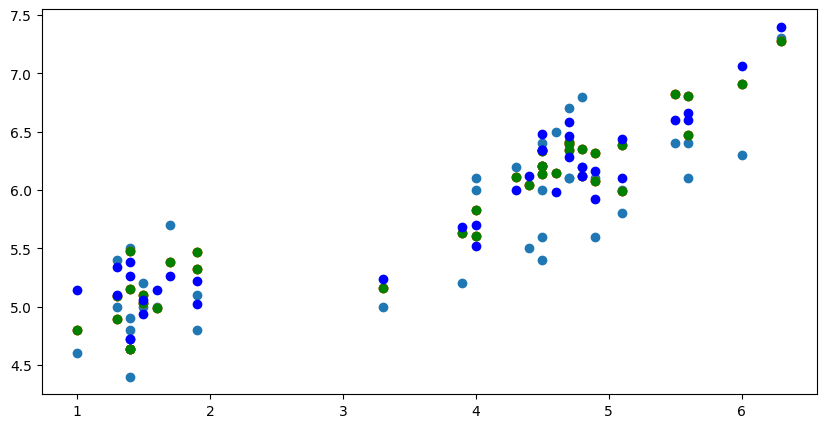

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(X_test['petal length (cm)'], y_test, label='y_test')
plt.scatter(X_test['petal length (cm)'], lg_y, c='y', label='lg_y')
plt.scatter(X_test['petal length (cm)'], De_y, c='r', label='De_y')
plt.scatter(X_test['petal length (cm)'], Rd_y, c='g', label='Rd_y')
plt.scatter(X_test['petal length (cm)'], KN_y, c='b', label='KN_y')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show() 